<a href="https://colab.research.google.com/github/ehdrb1023/GraduationProject/blob/main/GSAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. 구글 드라이브 연동 (실행 후 링크나 팝업창에서 권한 허용 눌러줘!)
from google.colab import drive
import os
import urllib.request

drive.mount('/content/drive')

# 2. 구글 드라이브 내에 졸업프로젝트 전용 데이터 폴더 생성
drive_data_path = '/content/drive/MyDrive/Colab_Data'
os.makedirs(drive_data_path, exist_ok=True)

# 3. CIFAR-10 압축본 다운로드 URL 지정 (fast.ai의 초고속 미러 서버)
cifar_url = 'https://s3.amazonaws.com/fast-ai-imageclas/cifar10.tgz'
destination_path = os.path.join(drive_data_path, 'cifar10.tgz')

# 4. 다운로드 시작
if not os.path.exists(destination_path):
    print("🚀 구글 드라이브로 CIFAR-10 압축 파일 다운로드를 시작합니다...")
    print("대략 10초~20초 정도 소요됩니다. 잠시만 기다려주세요.")

    urllib.request.urlretrieve(cifar_url, destination_path)

    print("\n✅ 다운로드 완료!")
    print(f"파일 저장 위치: {destination_path}")
    print(f"현재 파일 크기: {os.path.getsize(destination_path) / (1024*1024):.2f} MB")
else:
    print("✨ 이미 구글 드라이브에 cifar10.tgz 파일이 안전하게 존재합니다!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✨ 이미 구글 드라이브에 cifar10.tgz 파일이 안전하게 존재합니다!


In [ ]:
import os
import time
import tarfile
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ 현재 사용 중인 장치: {device}\n")

# ==========================================
# 1. 초고속 데이터 압축 해제 (Drive -> Colab Local)
# ==========================================
drive_zip_path = '/content/drive/MyDrive/Colab_Data/cifar10.tgz'
local_extract_path = '/content/'
local_data_path = '/content/cifar10'  # fast.ai 압축을 풀면 나오는 기본 폴더명

if not os.path.exists(local_data_path):
    print("📦 구글 드라이브에서 코랩 로컬로 데이터를 푸는 중... (약 10~15초 소요)")
    with tarfile.open(drive_zip_path, 'r:gz') as tar:
        tar.extractall(path=local_extract_path)
    print("✅ 로컬 압축 해제 완료!\n")
else:
    print("✨ 이미 코랩 로컬에 데이터가 압축 해제되어 있습니다.\n")

# ==========================================
# 2. 데이터셋 및 데이터로더 설정 (Data Augmentation)
# ==========================================
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

train_dataset = datasets.ImageFolder(root=os.path.join(local_data_path, 'train'), transform=transform_train)
test_dataset = datasets.ImageFolder(root=os.path.join(local_data_path, 'test'), transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)

print(f"📊 학습 데이터: {len(train_dataset)}장 | 테스트 데이터: {len(test_dataset)}장 준비 완료\n")

🖥️ 현재 사용 중인 장치: cuda

📦 구글 드라이브에서 코랩 로컬로 데이터를 푸는 중... (약 10~15초 소요)


/tmp/ipykernel_1233/2377517764.py:23: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=local_extract_path)


✅ 로컬 압축 해제 완료!

📊 학습 데이터: 50000장 | 테스트 데이터: 10000장 준비 완료



In [ ]:
# ==========================================
# 3. 모델 정의 (ResNet-18 for CIFAR-10)
# ==========================================
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

print("✅ ResNet-18 모델 로드 및 CIFAR-10 커스텀 완료!\n")

✅ ResNet-18 모델 로드 및 CIFAR-10 커스텀 완료!



In [ ]:
# ==========================================
# 4. GSAM 옵티마이저 구현
# ==========================================
class GSAM(optim.Optimizer):
    """
    ascent_step : w -> w + rho * g/||g||   (SAM과 동일한 ascent)
    descent_step: w 복원 후, g와 g_hat(perturbed gradient)을 직교분해하여
                  g_gsam = g_hat - alpha * g_perp 로 base_optimizer 업데이트
    """
    def __init__(self, params, base_optimizer, rho=0.05, alpha=0.05, **kwargs):
        assert rho >= 0
        defaults = dict(rho=rho, alpha=alpha, **kwargs)
        super().__init__(params, defaults)
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups = self.base_optimizer.param_groups
        self.defaults.update(self.base_optimizer.defaults)

    @torch.no_grad()
    def ascent_step(self, zero_grad=False):
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group['rho'] / (grad_norm + 1e-12)
            for p in group['params']:
                if p.grad is None:
                    continue
                self.state[p]['g'] = p.grad.clone()   # 원본 그래디언트 g 저장
                e_w = p.grad * scale.to(p)
                p.add_(e_w)
                self.state[p]['e_w'] = e_w
        if zero_grad:
            self.zero_grad()

    @torch.no_grad()
    def descent_step(self, zero_grad=False):
        # 1) w_adv -> w 복원
        for group in self.param_groups:
            for p in group['params']:
                if 'e_w' not in self.state[p]:
                    continue
                p.sub_(self.state[p]['e_w'])

        # 2) 전역 내적 <g, g_hat>, ||g_hat||^2 계산 (평행 성분 계수)
        device = self.param_groups[0]['params'][0].device
        inner = torch.zeros(1, device=device)
        ghat_sq = torch.zeros(1, device=device)
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None or 'g' not in self.state[p]:
                    continue
                g = self.state[p]['g']
                g_hat = p.grad
                inner += (g * g_hat).sum()
                ghat_sq += g_hat.pow(2).sum()
        coef = inner / (ghat_sq + 1e-12)

        # 3) g_perp = g - coef * g_hat,  g_gsam = g_hat - alpha * g_perp
        for group in self.param_groups:
            alpha = group['alpha']
            for p in group['params']:
                if p.grad is None or 'g' not in self.state[p]:
                    continue
                g = self.state[p]['g']
                g_hat = p.grad
                g_perp = g - coef * g_hat
                p.grad = g_hat - alpha * g_perp

        self.base_optimizer.step()
        if zero_grad:
            self.zero_grad()

    def _grad_norm(self):
        shared_device = self.param_groups[0]['params'][0].device
        return torch.norm(torch.stack([
            p.grad.norm(p=2).to(shared_device)
            for group in self.param_groups for p in group['params']
            if p.grad is not None
        ]), p=2)

    def zero_grad(self, set_to_none=True):
        self.base_optimizer.zero_grad(set_to_none=set_to_none)

print("✅ GSAM 옵티마이저 정의 완료!\n")

✅ GSAM 옵티마이저 정의 완료!



In [ ]:
# ==========================================
# 5. 평가 함수 + 독립 Sharpness 측정 함수
# ==========================================
def evaluate(model_to_eval, loader):
    model_to_eval.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model_to_eval(inputs)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    return 100. * correct / total

def measure_sharpness(model_to_probe, criterion, data_loader, device, rho=0.05, n_batches=5):
    """SAM 스타일 ascent로 측정한 sharpness: L(w+eps) - L(w) 평균 (GSAM의 학습용 rho와는
    독립적으로, 학습에 쓰이지 않은 새 배치/새 그래디언트 방향으로 측정하는 교차 검증용 지표).
    값이 클수록 뾰족한(sharp) minima, 작을수록 평평한(flat) minima."""
    model_to_probe.eval()
    diffs = []
    it = iter(data_loader)
    for _ in range(n_batches):
        try:
            inputs, targets = next(it)
        except StopIteration:
            it = iter(data_loader)
            inputs, targets = next(it)
        inputs, targets = inputs.to(device), targets.to(device)

        with torch.no_grad():
            loss_w = criterion(model_to_probe(inputs), targets).item()

        model_to_probe.zero_grad()
        loss = criterion(model_to_probe(inputs), targets)
        loss.backward()

        grad_norm = torch.norm(torch.stack([
            p.grad.norm(p=2) for p in model_to_probe.parameters() if p.grad is not None
        ]), p=2)
        scale = rho / (grad_norm + 1e-12)

        e_ws = []
        with torch.no_grad():
            for p in model_to_probe.parameters():
                if p.grad is None:
                    continue
                e_w = p.grad * scale
                p.add_(e_w)
                e_ws.append((p, e_w))

        with torch.no_grad():
            loss_w_eps = criterion(model_to_probe(inputs), targets).item()
            for p, e_w in e_ws:
                p.sub_(e_w)

        model_to_probe.zero_grad()
        diffs.append(loss_w_eps - loss_w)

    model_to_probe.train()
    return sum(diffs) / len(diffs)

print("✅ Sharpness 측정 함수 정의 완료!\n")

✅ Sharpness 측정 함수 정의 완료!



In [ ]:
# ==========================================
# 6. GSAM 학습 루프 (히스토리 기록 포함)
# ==========================================
criterion = nn.CrossEntropyLoss()
epochs = 50
sharpness_eval_interval = 5   # 몇 에폭마다 독립 Sharpness 스냅샷을 찍을지

optimizer = GSAM(model.parameters(), optim.SGD, rho=0.05, alpha=0.05,
                  lr=0.05, momentum=0.9, weight_decay=5e-4)

# 플롯을 위한 히스토리 기록용 딕셔너리
history = {'epoch': [], 'train_loss': [], 'test_acc': [], 'surrogate_gap': []}
sharpness_history = {'epoch': [], 'sharpness': []}

print("🚀 CIFAR-10 학습 시작 (GSAM)...\n")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    running_gap = 0.0
    start_time = time.time()

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        # 1) ascent: w -> w_adv, 원본 gradient g 저장
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.ascent_step(zero_grad=True)

        # 2) w_adv에서 그래디언트(g_hat) 계산 후 descent
        loss_adv = criterion(model(inputs), targets)
        loss_adv.backward()
        optimizer.descent_step(zero_grad=True)

        running_loss += loss.item()
        running_gap += (loss_adv.item() - loss.item())   # surrogate gap h(w) = L(w_adv) - L(w)

    epoch_time = time.time() - start_time
    train_loss = running_loss / len(train_loader)
    surrogate_gap = running_gap / len(train_loader)
    test_acc = evaluate(model, test_loader)

    history['epoch'].append(epoch + 1)
    history['train_loss'].append(train_loss)
    history['test_acc'].append(test_acc)
    history['surrogate_gap'].append(surrogate_gap)

    sharp_str = ""
    if (epoch + 1) % sharpness_eval_interval == 0 or epoch == epochs - 1:
        sharpness_val = measure_sharpness(model, criterion, train_loader, device, rho=0.05, n_batches=5)
        sharpness_history['epoch'].append(epoch + 1)
        sharpness_history['sharpness'].append(sharpness_val)
        sharp_str = f" | Sharpness: {sharpness_val:.4f}"

    print(f"[GSAM] Epoch [{epoch+1}/{epochs}] | Time: {epoch_time:.1f}s | "
          f"Train Loss: {train_loss:.4f} | Test Acc: {test_acc:.2f}% | "
          f"Surrogate Gap: {surrogate_gap:.4f}{sharp_str}")

print("\n🎉 GSAM 학습 종료!")
print(f"   - 최종 Train Loss     : {history['train_loss'][-1]:.4f}")
print(f"   - 최종 Test Acc       : {history['test_acc'][-1]:.2f}%")
print(f"   - 최종 Surrogate Gap  : {history['surrogate_gap'][-1]:.4f}")
print(f"   - 최종 Sharpness      : {sharpness_history['sharpness'][-1]:.4f}")

🚀 CIFAR-10 학습 시작 (GSAM)...

[GSAM] Epoch [1/50] | Time: 43.4s | Train Loss: 1.9398 | Test Acc: 44.48% | Surrogate Gap: 0.0957
[GSAM] Epoch [2/50] | Time: 42.5s | Train Loss: 1.4553 | Test Acc: 51.99% | Surrogate Gap: 0.0570
[GSAM] Epoch [3/50] | Time: 43.9s | Train Loss: 1.2497 | Test Acc: 58.97% | Surrogate Gap: 0.0603
[GSAM] Epoch [4/50] | Time: 46.8s | Train Loss: 1.1091 | Test Acc: 64.05% | Surrogate Gap: 0.0627
[GSAM] Epoch [5/50] | Time: 47.0s | Train Loss: 1.0112 | Test Acc: 65.29% | Surrogate Gap: 0.0636 | Sharpness: 0.1697
[GSAM] Epoch [6/50] | Time: 49.3s | Train Loss: 0.9429 | Test Acc: 66.20% | Surrogate Gap: 0.0646
[GSAM] Epoch [7/50] | Time: 48.6s | Train Loss: 0.8848 | Test Acc: 70.01% | Surrogate Gap: 0.0653
[GSAM] Epoch [8/50] | Time: 48.1s | Train Loss: 0.8356 | Test Acc: 71.56% | Surrogate Gap: 0.0661
[GSAM] Epoch [9/50] | Time: 49.4s | Train Loss: 0.7890 | Test Acc: 72.44% | Surrogate Gap: 0.0668
[GSAM] Epoch [10/50] | Time: 49.2s | Train Loss: 0.7574 | Test Acc: 72

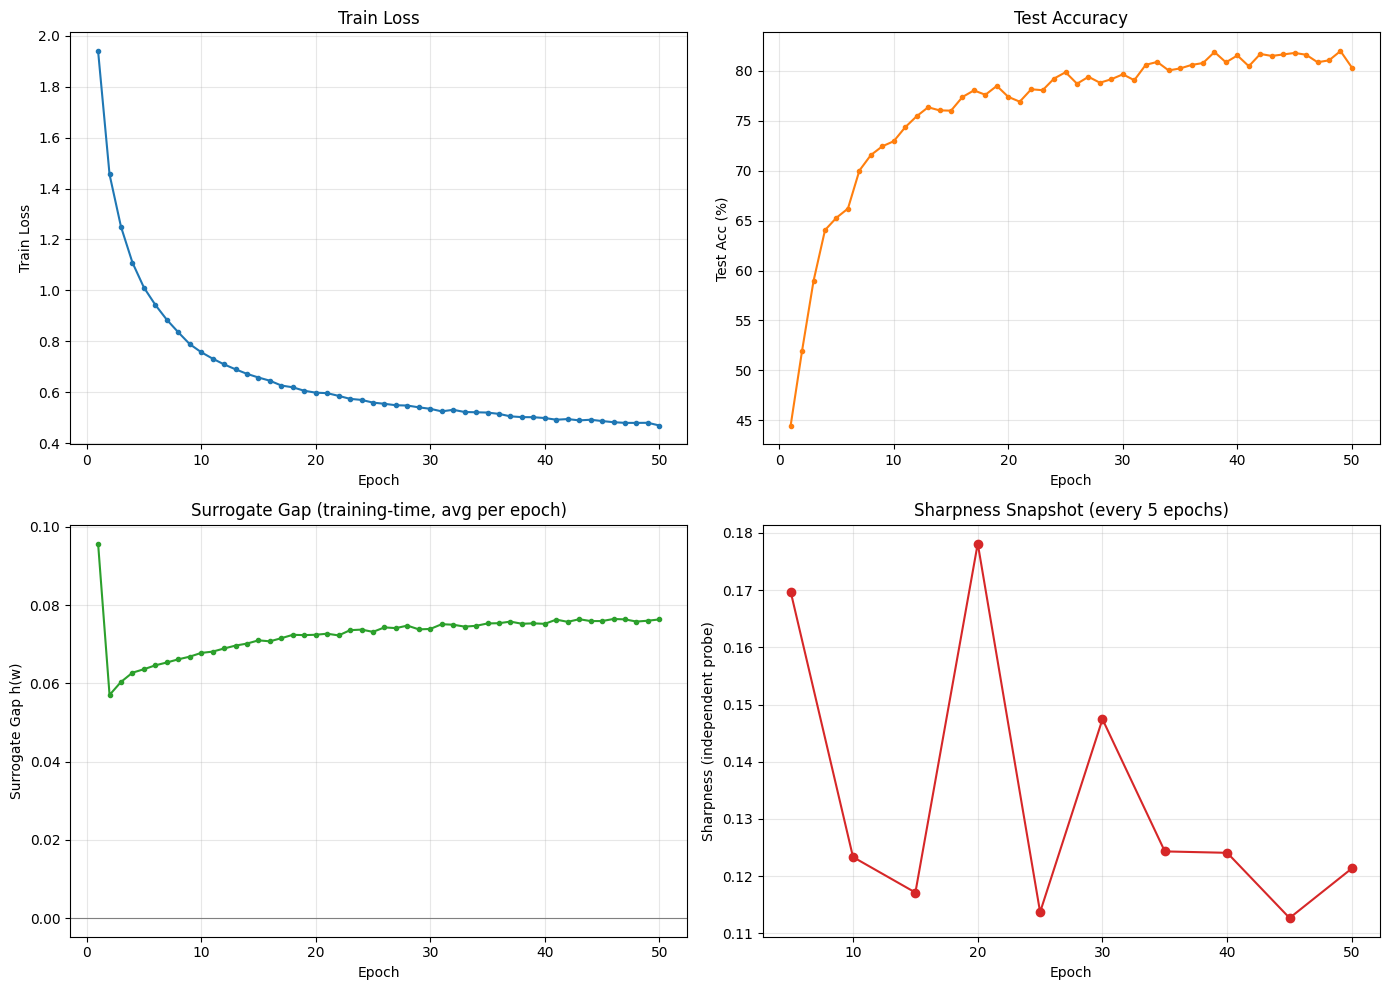


📊 요약
   - 최종 Train Loss     : 0.4695
   - 최종 Test Acc       : 80.32%
   - 최종 Surrogate Gap  : 0.0763
   - 최종 Sharpness      : 0.1214


In [ ]:
# ==========================================
# 7. 결과 시각화
# ==========================================
# (참고: matplotlib 기본 폰트는 한글 글리프를 지원하지 않아 그래프 안 텍스트가
#  깨져 보일 수 있어서, 그래프 라벨/제목은 영어로 표기합니다. 콘솔 출력은 한글 그대로.)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Train Loss
ax = axes[0, 0]
ax.plot(history['epoch'], history['train_loss'], color='tab:blue', marker='o', markersize=3)
ax.set_xlabel('Epoch'); ax.set_ylabel('Train Loss'); ax.set_title('Train Loss')
ax.grid(alpha=0.3)

# 2. Test Accuracy
ax = axes[0, 1]
ax.plot(history['epoch'], history['test_acc'], color='tab:orange', marker='o', markersize=3)
ax.set_xlabel('Epoch'); ax.set_ylabel('Test Acc (%)'); ax.set_title('Test Accuracy')
ax.grid(alpha=0.3)

# 3. Surrogate Gap h(w) (training-time, 매 배치 free)
ax = axes[1, 0]
ax.plot(history['epoch'], history['surrogate_gap'], color='tab:green', marker='o', markersize=3)
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Epoch'); ax.set_ylabel('Surrogate Gap h(w)')
ax.set_title('Surrogate Gap (training-time, avg per epoch)')
ax.grid(alpha=0.3)

# 4. 독립 Sharpness 스냅샷
ax = axes[1, 1]
ax.plot(sharpness_history['epoch'], sharpness_history['sharpness'],
         color='tab:red', marker='o', markersize=6)
ax.set_xlabel('Epoch'); ax.set_ylabel('Sharpness (independent probe)')
ax.set_title(f'Sharpness Snapshot (every {sharpness_eval_interval} epochs)')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/gsam_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 요약")
print(f"   - 최종 Train Loss     : {history['train_loss'][-1]:.4f}")
print(f"   - 최종 Test Acc       : {history['test_acc'][-1]:.2f}%")
print(f"   - 최종 Surrogate Gap  : {history['surrogate_gap'][-1]:.4f}")
print(f"   - 최종 Sharpness      : {sharpness_history['sharpness'][-1]:.4f}")